In [1]:
import matplotlib.pyplot as plt
import numpy             as np
import scipy.io.wavfile  as siw
import sys
import copy

In [2]:
# ------------------------- read in and setup-----------------------------

# Read in sound file, which is a (mono) wave file; the primary information 
# gets stored in these pieces:
#    rate : sampling rate (units of Hz)
#    data : 1- or 2-D array of time series.
#           In the case of a 2D array, we need to transpose for dimensions
#    N    : how many time points in the data storage array
infile_wav  = '07062015_lions_mono_short.wav'
rate, data  = siw.read(infile_wav)
N           = len(data)

# prepare for output, by determining a couple useful pieces of information
#    dtype_dat : what 'dtype' does wave file data have?
#    out_base  : make a 'base name' for the output file
dtype_dat   = data.dtype.name      # 
out_base    = infile_wav.replace('.wav', '') 

# ***** check the values of the items made above, to know what they are
# rate, data, N, dtype_dat, out_base

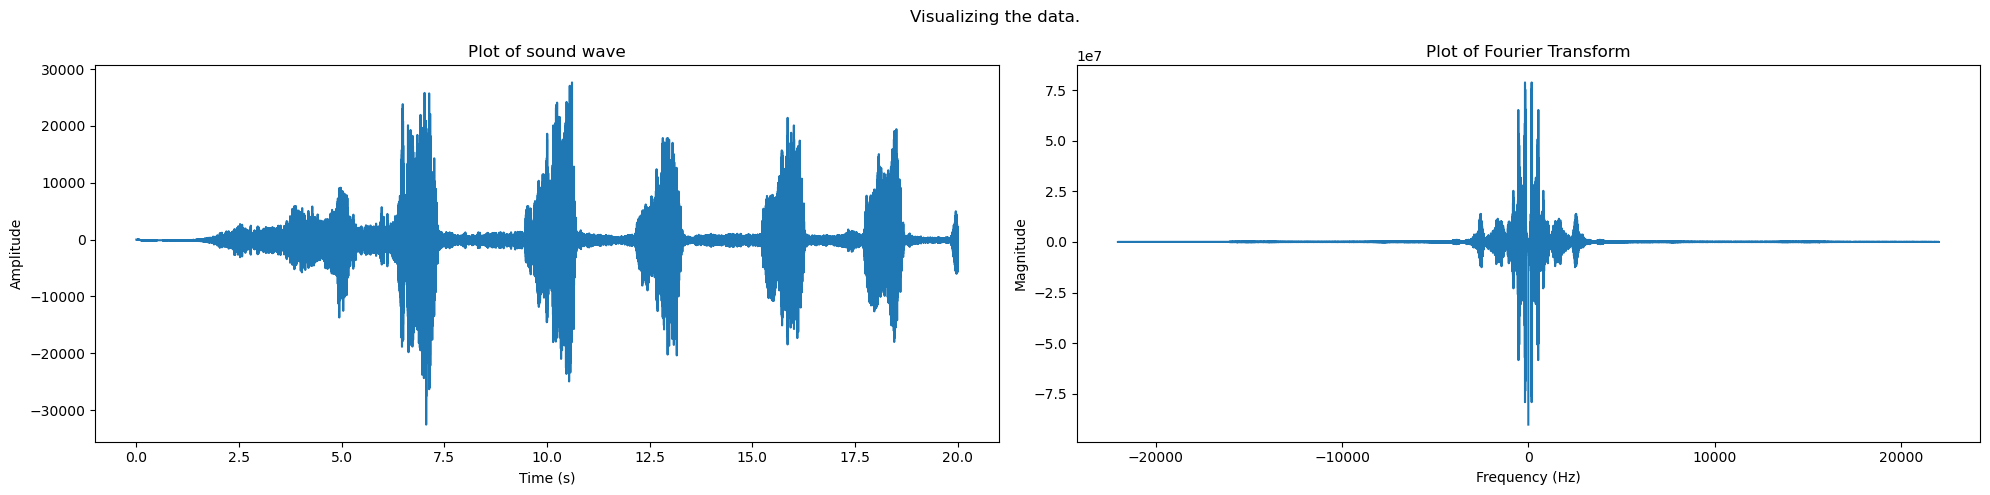

In [ ]:
# ------------------------- do processing -----------------------------

# example of copying the data
x = copy.deepcopy(data)
X = np.fft.fft(x)

# ***** make a plot!
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

time = np.arange(N) / rate
ax[0].plot(time, x)
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].set_title('Plot of sound wave')


freqs = np.fft.fftfreq(N, d=1/rate)
ax[1].plot(freqs, np.real(X))
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Magnitude')
ax[1].set_title('Plot of Fourier Transform')

plt.suptitle('Visualizing the data.')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Plot of Fourier Transform')

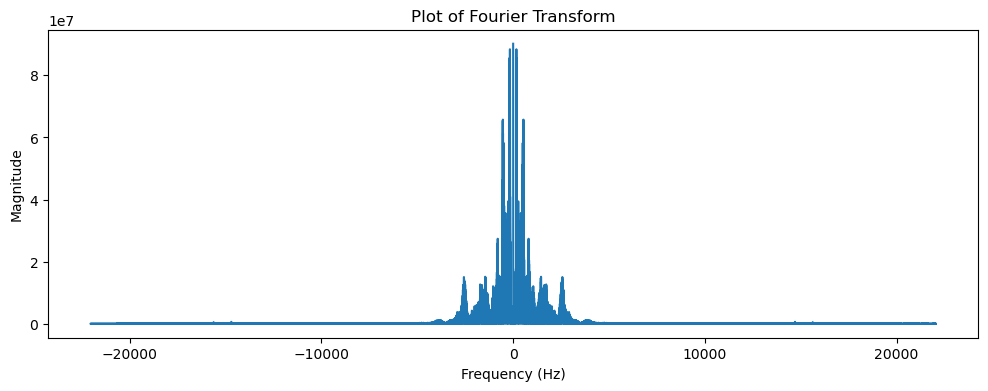

In [12]:
freqs = np.fft.fftfreq(N, d=1/rate)
plt.figure(figsize=(12, 4))
plt.plot(freqs, np.abs(X))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Plot of Fourier Transform')


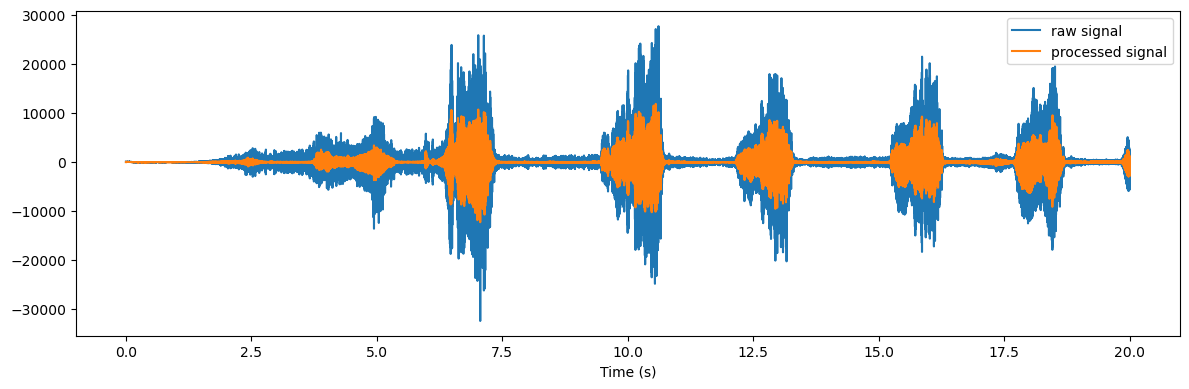

In [15]:
# ***** process! Use FFT, then create a LOW PASS FILTER to try to 
# eliminate the high frequency sounds, then use IFFT to get a new
# time series
# -> then plot this, and save it out to a file, as shown below


H = np.zeros(N)

start = 0
end = N//30

# H[start:end] = 1/(end-start+1) 
H[start:end] = 1
# H[(9*N)//10:N-1] = 1

C = X*H

new_x = np.fft.ifft(C)

x_normalized = x / np.max(np.abs(x))
new_x_normalized = np.abs(new_x) / np.max(np.abs(new_x))

plt.figure(figsize=(12,4))
# plt.plot(x, label='raw signal')
# plt.plot(np.real(new_x), label='processed signal')

time = np.arange(len(new_x)) / rate
plt.plot(time, x, label='raw signal')
plt.plot(time, np.real(new_x), label='processed signal')
plt.xlabel('Time (s)')

plt.legend()
plt.tight_layout()
plt.show()


In [89]:
# ---------------------- output wav files -----------------------------


# example of writing out the original wave: make an output name, and
# provide correct sampling rate and dtype for writing data
out_file = out_base + '_x.wav'
siw.write(out_file, rate, x.astype(dtype_dat))

# ***** write some more output
out_file = 'new' + '_x.wav'
siw.write(out_file, rate, new_x.astype(dtype_dat))

# celebrate
print("Done!")

Done!


/tmp/ipykernel_73376/1157015281.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  siw.write(out_file, rate, new_x.astype(dtype_dat))
